In [25]:
from typing import TypedDict, Annotated
from dotenv import load_dotenv

load_dotenv()

from langchain.chat_models import init_chat_model
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage

In [16]:
llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")

In [21]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State) -> State:
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("chatbot_node", chatbot)

builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()

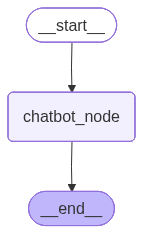

In [22]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
state = graph.invoke({'messages': ["hey, my name is dhanuka. what is your name?"]})

{'messages': [HumanMessage(content='hey, my name is dhanuka. what is your name?', additional_kwargs={}, response_metadata={}, id='32b4570a-26ab-46dd-804b-e2c47959eb4f'),
  AIMessage(content='I do not have a name. I am a large language model, trained by Google.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e222d-89db-7e73-8c81-887400f99a56-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 18, 'total_tokens': 32, 'input_token_details': {'cache_read': 0}})]}

In [24]:
graph.invoke({'messages': ["oh really? what is google?"]})

{'messages': [HumanMessage(content='oh really? what is google?', additional_kwargs={}, response_metadata={}, id='d4f2ed1c-0bdc-47aa-a3b6-0947835b931d'),
  AIMessage(content="Yes, really! 😊\n\n**Google is a multinational technology company that specializes in Internet-related services and products.**\n\nThink of it as a giant digital hub that offers a wide range of tools and platforms that help people find information, connect with others, and get things done online.\n\nHere's a breakdown of what Google is most known for:\n\n*   **Search Engine:** This is what Google is most famous for. The **Google Search engine** is the primary way most people find information on the internet. You type in a question or keywords, and Google scours the web to present you with relevant websites, images, videos, and more.\n\n*   **Internet Services:** Beyond search, Google offers a suite of essential internet services:\n    *   **Gmail:** A popular free email service.\n    *   **Google Maps:** For navigat

In [30]:
state = None

while True:
    input_message = input("enter your message: ")

    if input_message.lower() in ["exit", "quit", "bye"]:
        print("chat ended.")
        break

    print("Human: ", input_message)

    if state == None:
        state: State = {
            "messages": [HumanMessage(input_message)]
        }
    else:
        state["messages"].append(HumanMessage(input_message))
    
    state = graph.invoke(state)
    print("AI: ", state["messages"][-1].content)
    

Human:  hi
AI:  Hello! How can I help you today?
Human:  who is the owner of amazon
AI:  The owner of Amazon is **Jeff Bezos**.

He is the founder and former CEO of Amazon, and he remains the largest individual shareholder. While a company is technically owned by its shareholders, Jeff Bezos holds the most significant stake and is widely considered the owner.
Human:  does he still alive?
AI:  Yes, **Jeff Bezos is still alive.**
chat ended.
